In [1]:
from pricing.heston_option_pricing import train_network as train_network_heston, PINN as PINN_heston
from pricing.hd_option_pricing import train_network as train_network_hd, PINN as PINN_hd
from pricing.two_d_option_pricing import train_network as train_network_2d, PINN as PINN_2d
from support_tools.testing_tools import heston_2d_slice_test, bs_2d_slice_test
from support_tools.graphing_tools import plot_convergence, plot_3d_result

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import numpy as np

In [19]:
from support_tools.analytical_pricing_tools import heston_price

In [35]:

heston_price(100., 100., 1.0, 0.05, 0.0, 0.04, 2.0, 0.04, 0.3, -0.7, "Call", verbose=False)

(np.float64(10.316362709319698),
 np.float64(1.5457494560457168e-06),
 {'P1': np.float64(0.6910886606780813),
  'P2': np.float64(0.618068594643692),
  'P1_integral': 0.600322732570573,
  'P2_integral': 0.3709234295522942,
  'P1_abs_error': 3.3545130530103495e-08,
  'P2_abs_error': 3.691308544592764e-08,
  'P1_prob_abs_error': 1.0677746681057645e-08,
  'P2_prob_abs_error': 1.1749800026985768e-08,
  'call_price': np.float64(10.316362709319698),
  'price_abs_error_proxy': np.float64(1.5457494560457168e-06)})

# Pricing options under Two-Dimensional Black-Scholes model

In [2]:
pinn_2d = PINN_2d(x_min=-5.0,
    x_max=5.0,
    T=4.0,
    r=0.05,
    sigma=0.2,
    call_put="Call",
    hidden = 50, depth = 5).to(device)

In [9]:
11.45 * 60

687.0

In [3]:
history = train_network_2d(
    pinn=pinn_2d,
    n_pde=2000,
    n_boundary=1000,
    epochs=40000,
    save_model=True,
    best_model_path=r'trained_models/two_d.pt',
    lambda_boundary=0.3,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=7e-3,
)

Epoch      1 | Time:       0.04s | LR: 7.000e-03 | Total: 8.125417e-01 | PDE_x: 9.764444e-04 | Terminal_x: 5.028131e-01 | Boundary_x: 1.867196e+00 | GradNorm: 5.263e-01 | Best: 8.125417e-01 @ 1
Epoch    100 | Time:       2.73s | LR: 7.000e-03 | Total: 6.173781e-01 | PDE_x: 6.881674e-06 | Terminal_x: 3.455659e-01 | Boundary_x: 1.481961e+00 | GradNorm: 3.940e-03 | Best: 6.026493e-01 @ 88
Epoch    200 | Time:       5.68s | LR: 7.000e-03 | Total: 5.354300e-01 | PDE_x: 4.477233e-02 | Terminal_x: 1.823547e-01 | Boundary_x: 1.331601e+00 | GradNorm: 6.850e-01 | Best: 4.788266e-01 @ 188
Epoch    300 | Time:       9.03s | LR: 6.999e-03 | Total: 3.868008e-01 | PDE_x: 5.070147e-03 | Terminal_x: 6.643854e-02 | Boundary_x: 1.161705e+00 | GradNorm: 2.226e-01 | Best: 3.821873e-01 @ 299
Epoch    400 | Time:      12.02s | LR: 6.998e-03 | Total: 3.427419e-01 | PDE_x: 2.779235e-02 | Terminal_x: 4.601583e-02 | Boundary_x: 9.731388e-01 | GradNorm: 5.793e-01 | Best: 3.284873e-01 @ 389
Epoch    500 | Time:   

In [10]:
%%timeit
pinn_2d.predict_price(150., 100., 1.0)

208 μs ± 16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


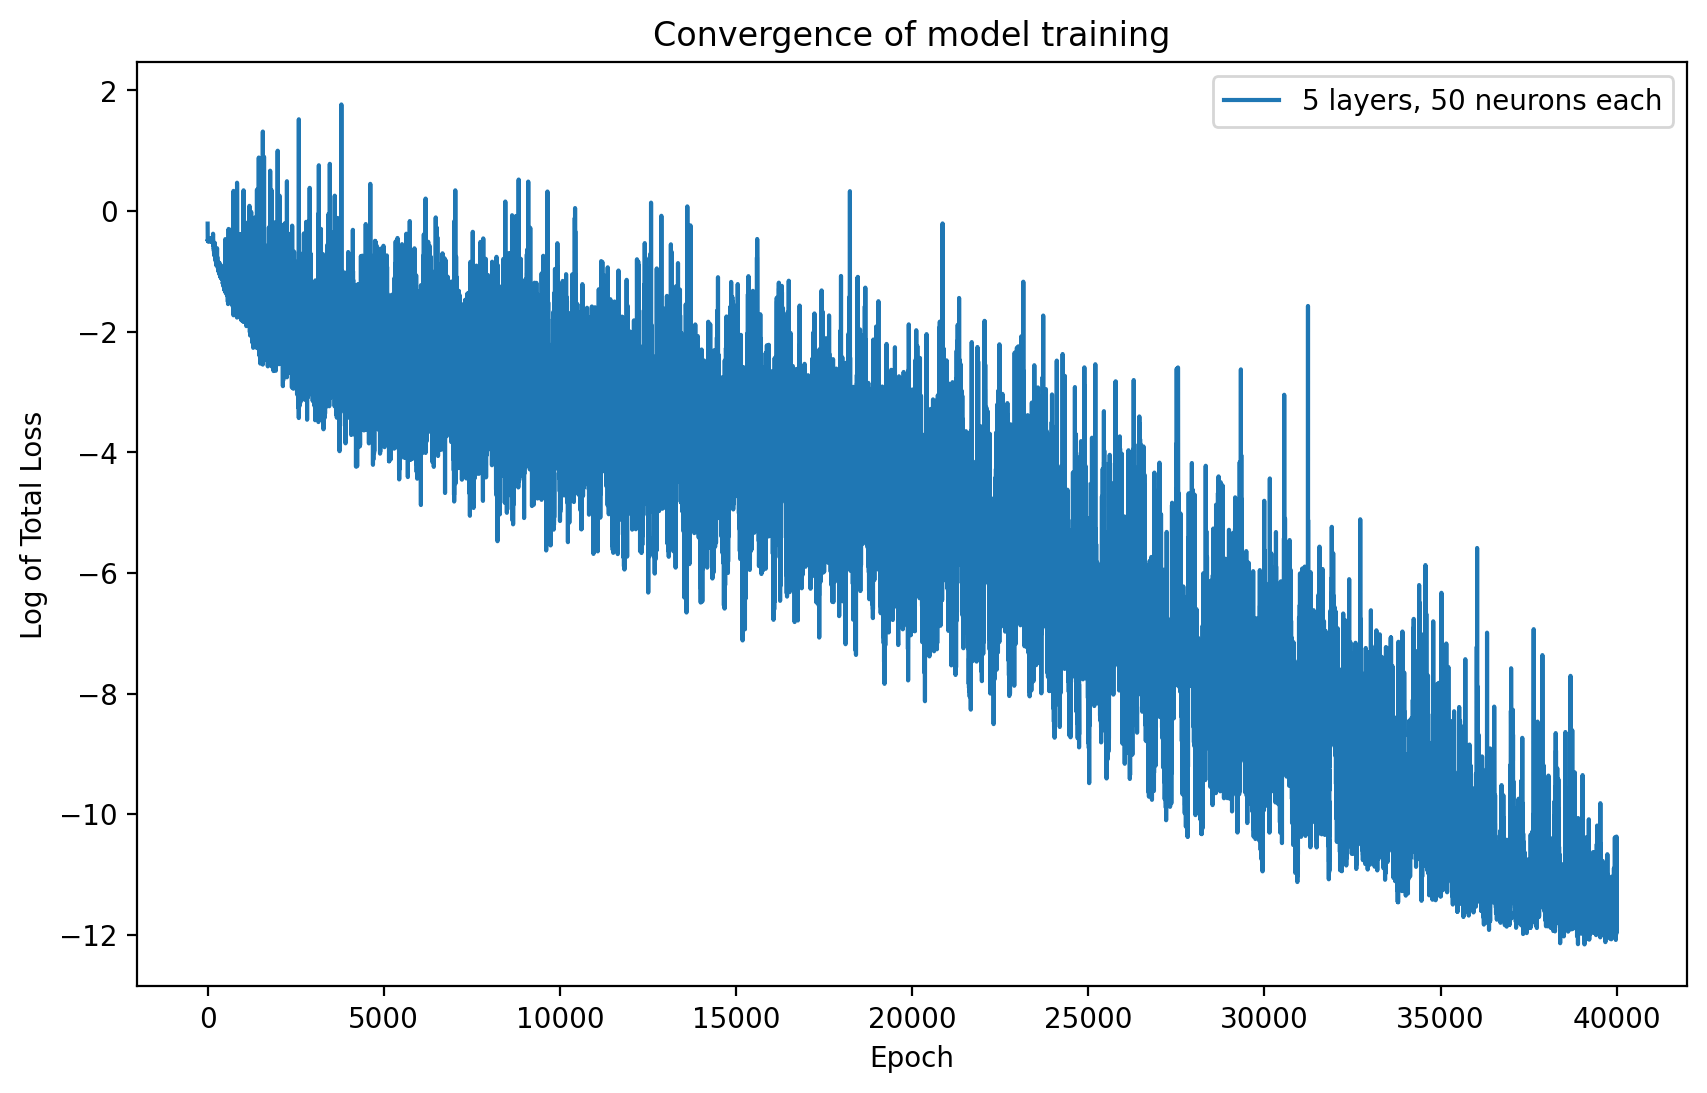

In [5]:
plot_convergence(history, x_axis = 'epochs')

In [8]:
results = bs_2d_slice_test(pinn_2d, return_values = True, r=0.05, sigma_bs=0.2, K=100, s_max=500, s_step=2)

MSE = 0.06458063839928935
RMSE = 0.2541272090888525
MAE = 0.2001143842366147


In [12]:
plot_3d_result(results, 'diff')

# Pricing options under High-Dimensional Black-Scholes model

In [2]:
pinn_hd = PINN_hd(x_min=-10.0,
    x_max=15.0,
    T=4.0,
    r_max=0.4,
    sigma_max=0.7,
    call_put="Call",
    hidden = 70, depth = 6).to(device)

In [3]:
history = train_network_hd(
    pinn=pinn_hd,
    n_pde=1000,
    n_boundary=500,
    epochs=5000,
    save_model=True,
    best_model_path=r'trained_models/hd.pt',
    lambda_boundary=0.3,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=1e-3,
)

Epoch      1 | Time:       0.27s | LR: 1.000e-03 | Total: 3.688228e+03 | PDE_x: 3.688228e+03 | Terminal_x: 5.752954e-04 | Boundary_x: 3.599894e-04 | GradNorm: 3.690e+05 | Best: 3.688228e+03 @ 1
Epoch    100 | Time:       3.83s | LR: 9.990e-04 | Total: 8.426683e-02 | PDE_x: 8.285136e-02 | Terminal_x: 1.197371e-03 | Boundary_x: 2.722650e-03 | GradNorm: 4.138e+01 | Best: 8.426683e-02 @ 100
Epoch    200 | Time:       7.50s | LR: 9.961e-04 | Total: 4.122501e-02 | PDE_x: 3.851130e-02 | Terminal_x: 2.059708e-03 | Boundary_x: 5.612865e-03 | GradNorm: 1.152e+01 | Best: 1.096915e-02 @ 196
Epoch    300 | Time:      11.27s | LR: 9.912e-04 | Total: 1.617116e-02 | PDE_x: 1.184911e-02 | Terminal_x: 3.273496e-03 | Boundary_x: 8.950973e-03 | GradNorm: 7.395e+00 | Best: 5.262325e-03 @ 228
Epoch    400 | Time:      14.79s | LR: 9.844e-04 | Total: 4.844637e-03 | PDE_x: 1.023217e-04 | Terminal_x: 3.497686e-03 | Boundary_x: 9.978241e-03 | GradNorm: 4.348e-02 | Best: 4.819749e-03 @ 395
Epoch    500 | Time:  

In [17]:
2.90*60

174.0

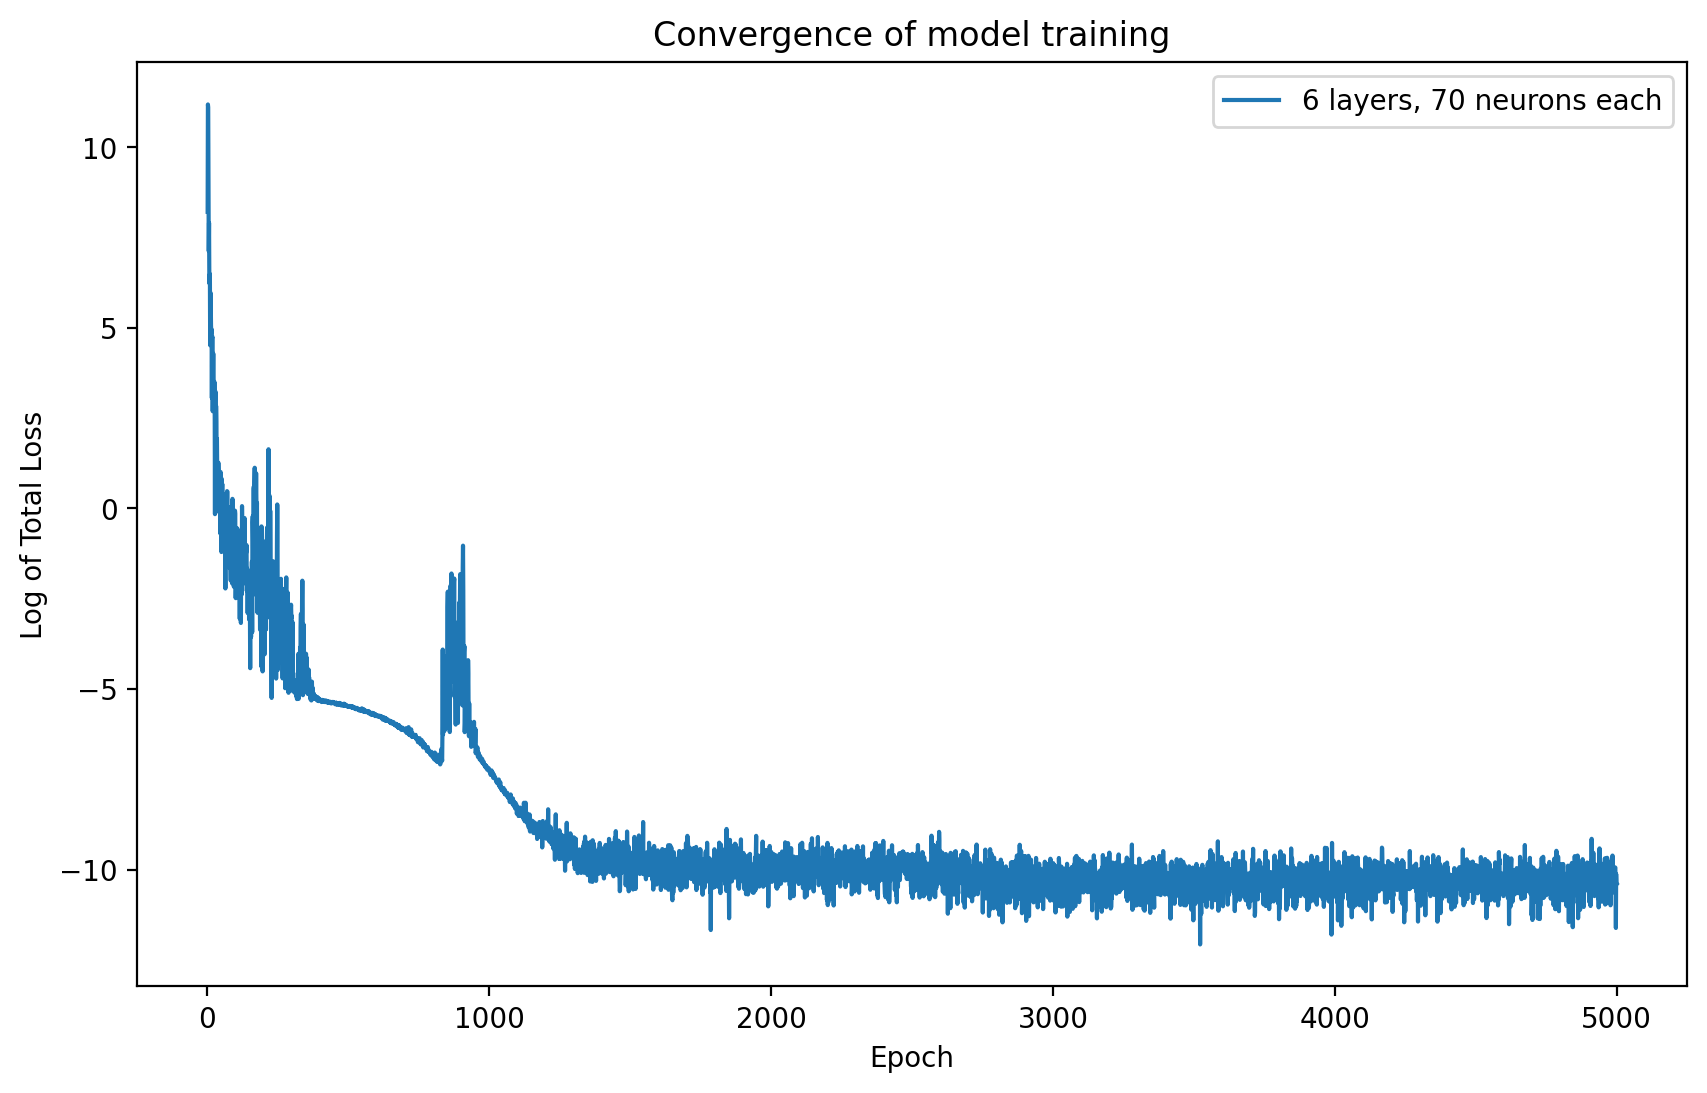

In [4]:
plot_convergence(history, x_axis = 'epochs')

In [18]:
%%timeit
pinn_hd.predict_price(150., 100., 1., 0.05, 0.2)

343 μs ± 26.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
results = bs_2d_slice_test(pinn_hd, r=0.05, sigma_bs=0.2, K=100, s_max=500, s_step=2, return_values=True)

MSE = 0.00029483281248802356
RMSE = 0.017170696330901188
MAE = 0.00651661471809747


In [16]:
results[2].max()

np.float64(0.009818440260510819)

In [19]:
# plot_3d_result(results, 'diff')

# Pricing options under Heston model

In [11]:
# setting up a model
pinn = PINN_heston(
    x_min=np.log(0.01),
    x_max=np.log(100.0),
    v_max=0.5,
    T=4.0,
    r_max=0.4,
    kappa_max=5.0,
    theta_max=0.5,
    sigma_max=0.5,
    call_put="Call",
    hidden=75,
    depth=6
).to(device)

In [12]:
# either train the model...
history = train_network_heston(
    pinn=pinn,
    N_pde=4000,
    N_boundary=1000,
    epochs=7000,
    sigma_mode="mean_reverting",
    save_model=True,
    best_model_path=r'trained_models/wide_moneyness_heston.pt',
    lambda_boundary=1.0,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=1e-4,               
)

Epoch      1 | Time:       0.24s | LR: 1.000e-04 | Total: 1.667718e+00 | PDE_x: 6.959864e-02 | Terminal_x: 1.292565e-01 | Boundary_x: 1.533491e+00 | GradNorm: 7.047e+01 | Best: 1.667718e+00 @ 1
Epoch    100 | Time:      16.70s | LR: 9.995e-05 | Total: 1.021717e-04 | PDE_x: 4.147723e-05 | Terminal_x: 3.352712e-05 | Boundary_x: 4.393090e-05 | GradNorm: 1.411e-02 | Best: 1.021717e-04 @ 100
Epoch    200 | Time:      33.07s | LR: 9.982e-05 | Total: 4.677402e-05 | PDE_x: 2.312072e-05 | Terminal_x: 1.293327e-05 | Boundary_x: 1.718666e-05 | GradNorm: 3.313e-02 | Best: 4.677402e-05 @ 200
Epoch    300 | Time:      49.70s | LR: 9.959e-05 | Total: 2.661875e-05 | PDE_x: 1.469257e-05 | Terminal_x: 5.430472e-06 | Boundary_x: 9.210945e-06 | GradNorm: 1.983e-03 | Best: 2.661875e-05 @ 300
Epoch    400 | Time:      66.30s | LR: 9.928e-05 | Total: 1.937577e-05 | PDE_x: 1.109181e-05 | Terminal_x: 3.404609e-06 | Boundary_x: 6.581654e-06 | GradNorm: 1.723e-02 | Best: 1.821433e-05 @ 395
Epoch    500 | Time:  

In [10]:
# ...or load the saved ones
state_dict = torch.load(r'trained_models/heston.pt', weights_only=True)['model_state_dict']
pinn.load_state_dict(state_dict)
pinn.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=75, bias=True)
    (1): Tanh()
    (2): Linear(in_features=75, out_features=75, bias=True)
    (3): Tanh()
    (4): Linear(in_features=75, out_features=75, bias=True)
    (5): Tanh()
    (6): Linear(in_features=75, out_features=75, bias=True)
    (7): Tanh()
    (8): Linear(in_features=75, out_features=75, bias=True)
    (9): Tanh()
    (10): Linear(in_features=75, out_features=75, bias=True)
    (11): Tanh()
    (12): Linear(in_features=75, out_features=1, bias=True)
  )
)

In [18]:
%%timeit
pinn.predict_price(100., 100., 0.04, 1.0, 0.05, 2.0, 0.04, 0.3, -0.7, 'mean_reverting')

580 μs ± 29.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


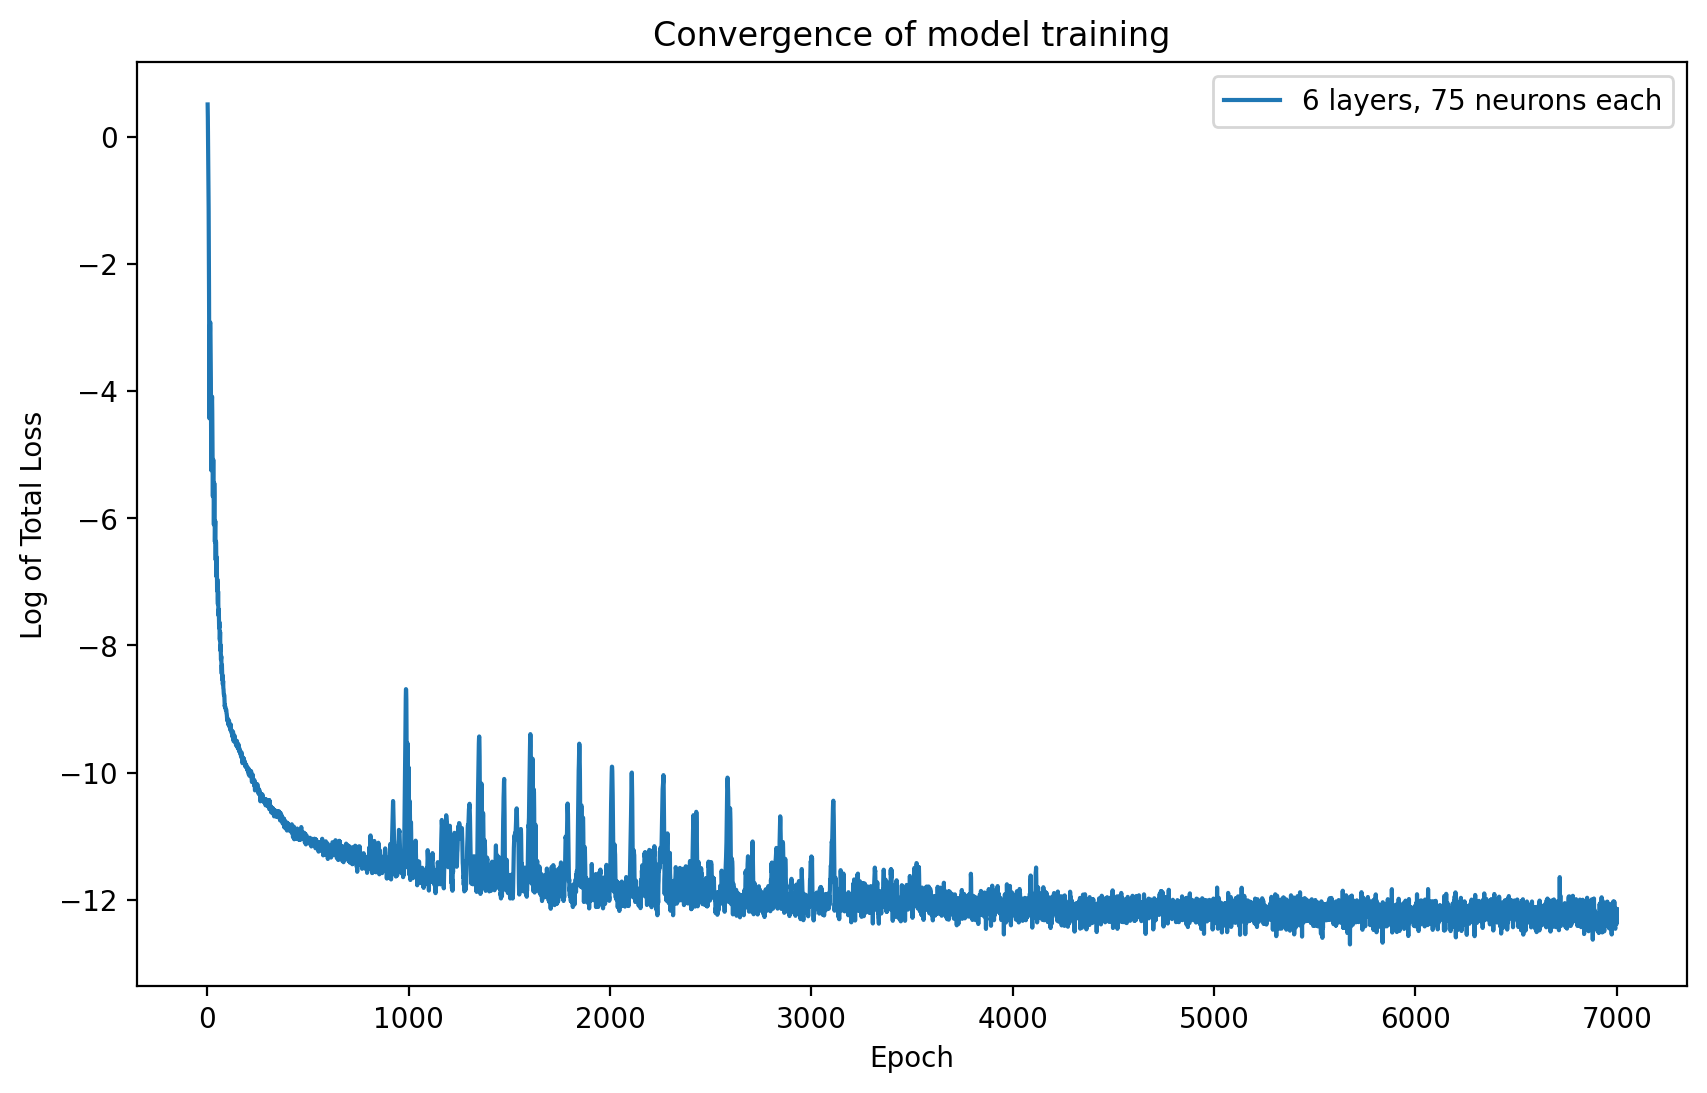

In [13]:
plot_convergence(history, x_axis = 'epochs')

In [14]:
# test the accuracy of the model against quasi-analytical pricing
results = heston_2d_slice_test(pinn = pinn, return_values = True)

MSE = 0.008498350744128368
RMSE = 0.09218649979323637
MAE = 0.08034515736268982


In [15]:
plot_3d_result(results, 'diff')

In [3]:
# testing multiple models
pinn_5_50 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=50, depth=5).to(device)
pinn_6_75 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=75, depth=6).to(device)
pinn_7_100 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=100, depth=7).to(device)

pinns = [pinn_5_50, pinn_6_75, pinn_7_100]
histories = []

for pinn in pinns:
    histories.append(train_network_heston(
        pinn=pinn,
        N_pde=4000,
        N_boundary=1000,
        epochs=7000,
        sigma_mode="mean_reverting",
        save_model=False, 
        lambda_boundary=1.0,
        lambda_terminal=0.5,   
        grad_clip=1.0,
        print_every=1000,
        lr=1e-4,               
    ))

Epoch      1 | Time:       1.25s | LR: 1.000e-04 | Total: 5.640021e+00 | PDE_x: 9.111318e-02 | Terminal_x: 5.659737e-01 | Boundary_x: 5.265921e+00 | GradNorm: 1.207e+02 | Best: 5.640021e+00 @ 1
Epoch   1000 | Time:      83.54s | LR: 9.554e-05 | Total: 3.431805e-05 | PDE_x: 1.850039e-05 | Terminal_x: 4.320330e-06 | Boundary_x: 1.365749e-05 | GradNorm: 6.490e-02 | Best: 3.271459e-05 @ 999
Epoch   2000 | Time:     166.36s | LR: 8.306e-05 | Total: 1.680814e-05 | PDE_x: 1.105754e-05 | Terminal_x: 1.211802e-06 | Boundary_x: 5.144700e-06 | GradNorm: 3.516e-02 | Best: 1.512946e-05 @ 1958
Epoch   3000 | Time:     247.27s | LR: 6.501e-05 | Total: 1.363725e-05 | PDE_x: 1.065429e-05 | Terminal_x: 8.296574e-07 | Boundary_x: 2.568130e-06 | GradNorm: 4.661e-03 | Best: 1.088053e-05 @ 2864
Epoch   4000 | Time:     328.27s | LR: 4.499e-05 | Total: 9.745225e-06 | PDE_x: 7.600248e-06 | Terminal_x: 5.869775e-07 | Boundary_x: 1.851487e-06 | GradNorm: 8.373e-03 | Best: 8.877591e-06 @ 3709
Epoch   5000 | Time

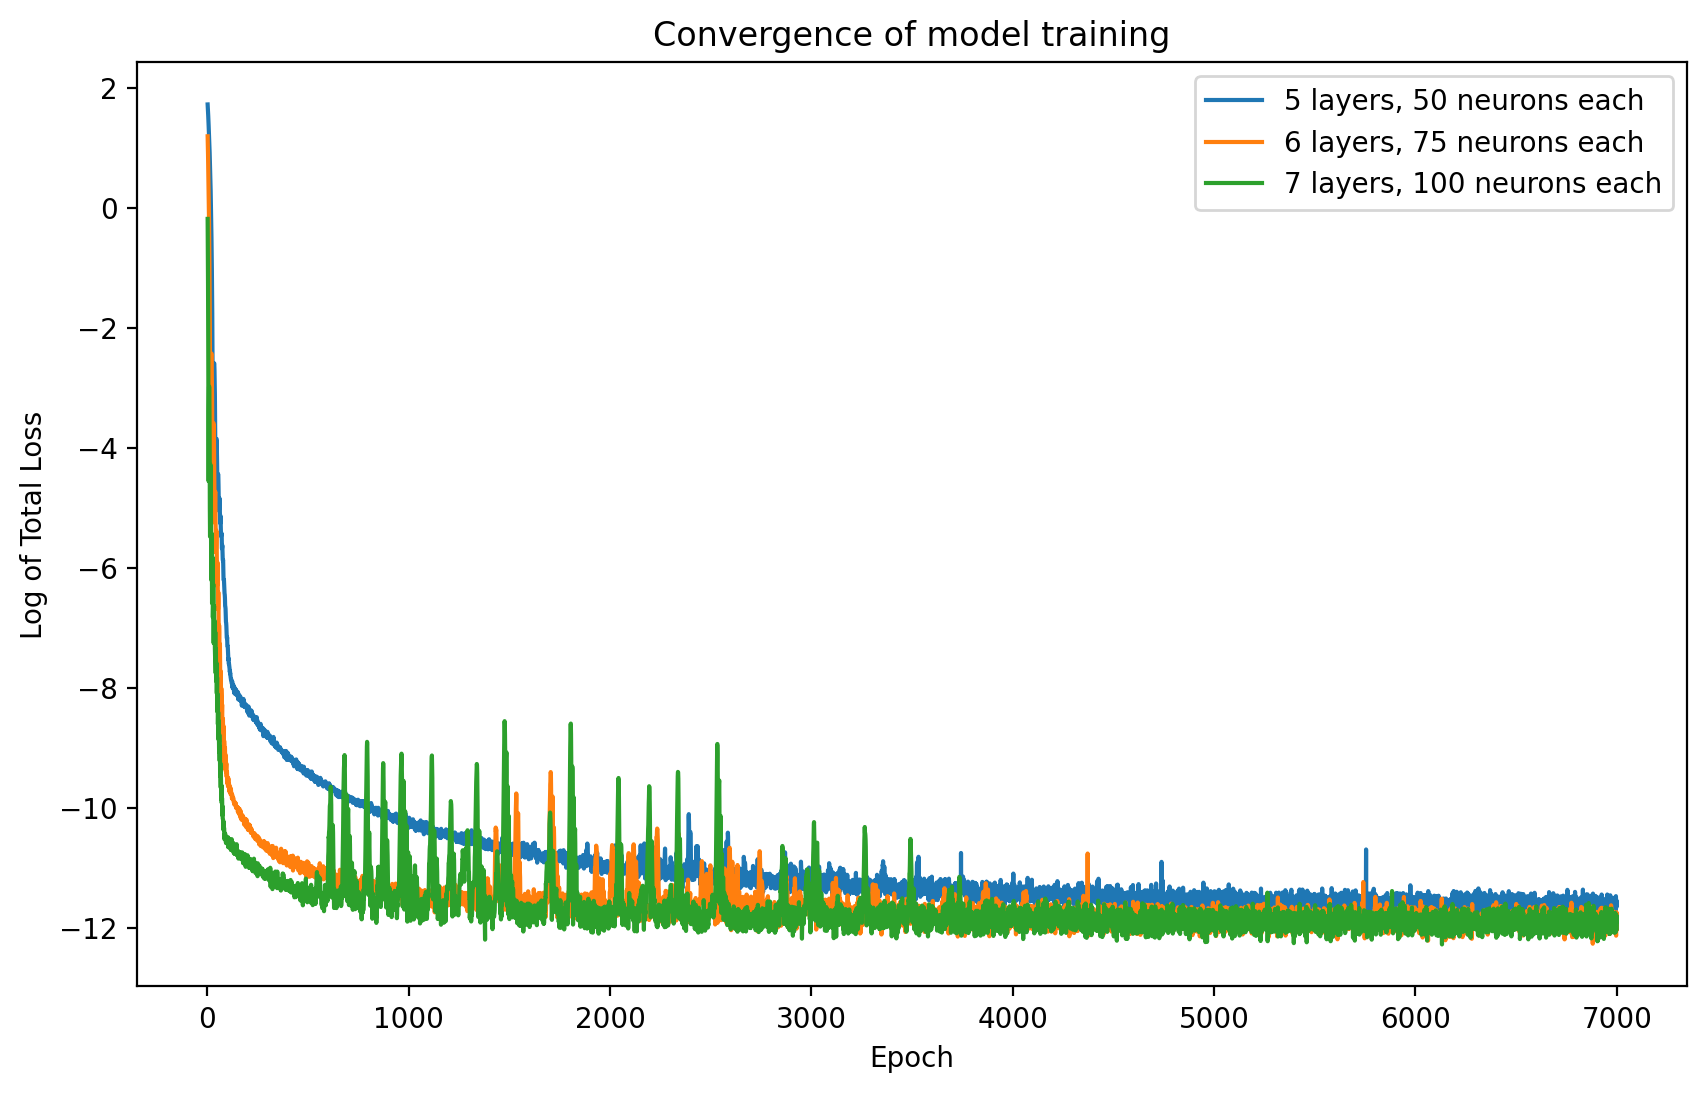

In [4]:
plot_convergence(histories, x_axis = 'epochs')

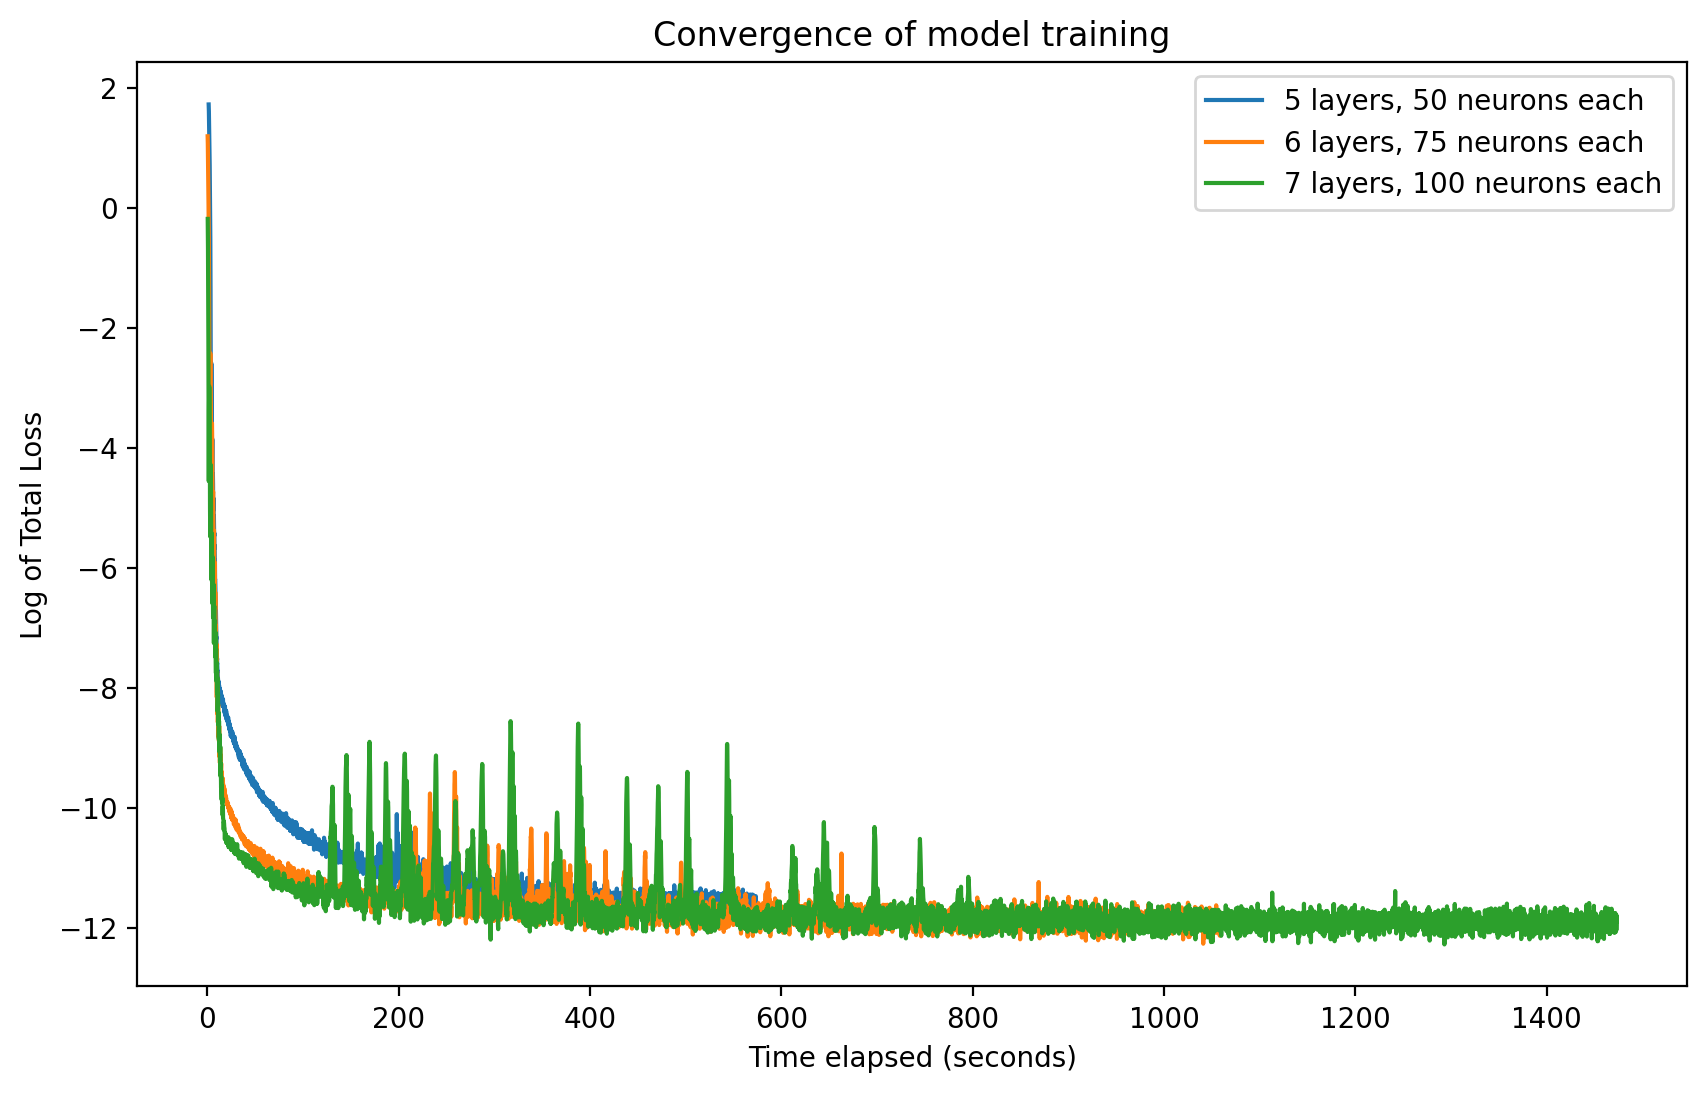

In [5]:
plot_convergence(histories, x_axis = 'elapsed_time')